### Power Plant Datasets

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


#### AT ----> Temperature
#### V ----> vacuum
#### AP ----> pressure
#### RH ---- humidity  

#### PE ----> produced energy/ produced outputs

In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [6]:
X.head()
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [7]:
# Split out data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
df.shape

(9568, 5)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

### converting our data into tensors

In [11]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)    # This will convert our X_train_scaled into tensors datasets
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)    # .view will change the dimension

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [12]:
type(X_train_scaled)

numpy.ndarray

In [13]:
type(y_train)

pandas.core.series.Series

#### Tensor Dataset and Data loader

In [14]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [15]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

### DEEP LEARNING

In [16]:
# Define out ANN model
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),       # nn.Linear(input_features, output_features)
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(6, 6),        # nn.Linear(input_features, output_features)
            nn.ReLU(),
    
            # output layer
            nn.Linear(6, 1),
        )

    def forward(self, x):
        return self.model(x)

In [17]:
import torch.optim as optim

model = ANN()

# loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())      #model.parameters()= weight, bias

#### Training ANN model


In [18]:
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0  # tot training loss in 1 epoch

    for xb, yb in train_loader:
        # xb : feature of 1 batch
        # yb : labels of 1 batch
        optimizer.zero_grad()

        outputs = model(xb)   # forward prop... predicted ouutputs for this batch
        loss = criterion(outputs, yb)    # compute loss
        loss.backward()   # back prop... compute gradients
        optimizer.step()     # params update

        running_loss += loss.item()    # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():   # no gradients computes
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            
            running_val_loss += loss
            
        epoch_val_loss = running_val_loss / len(test_loader)
        val_losses.append(epoch_val_loss)

        print(f"{epoch} {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = ${epoch_val_loss}")

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), "best_model.pt")    # saving model in .pt or .pth

0 1/100 ==> train loss = 206224.19251302083 & val loss = $204818.421875
1 2/100 ==> train loss = 199103.6591796875 & val loss = $189384.21875
2 3/100 ==> train loss = 172435.148046875 & val loss = $151264.59375
3 4/100 ==> train loss = 125562.91839192709 & val loss = $98485.125
4 5/100 ==> train loss = 74115.32727864584 & val loss = $52632.91796875
5 6/100 ==> train loss = 36921.793957519534 & val loss = $25878.17578125
6 7/100 ==> train loss = 21130.37774251302 & val loss = $17868.208984375
7 8/100 ==> train loss = 15839.09911702474 & val loss = $14000.28125
8 9/100 ==> train loss = 12562.645517985025 & val loss = $11086.73828125
9 10/100 ==> train loss = 9921.986287434896 & val loss = $8662.4833984375
10 11/100 ==> train loss = 7669.943420410156 & val loss = $6592.2412109375
11 12/100 ==> train loss = 5751.116854858398 & val loss = $4860.12548828125
12 13/100 ==> train loss = 4161.13402150472 & val loss = $3442.47607421875
13 14/100 ==> train loss = 2876.2956481933593 & val loss = $2

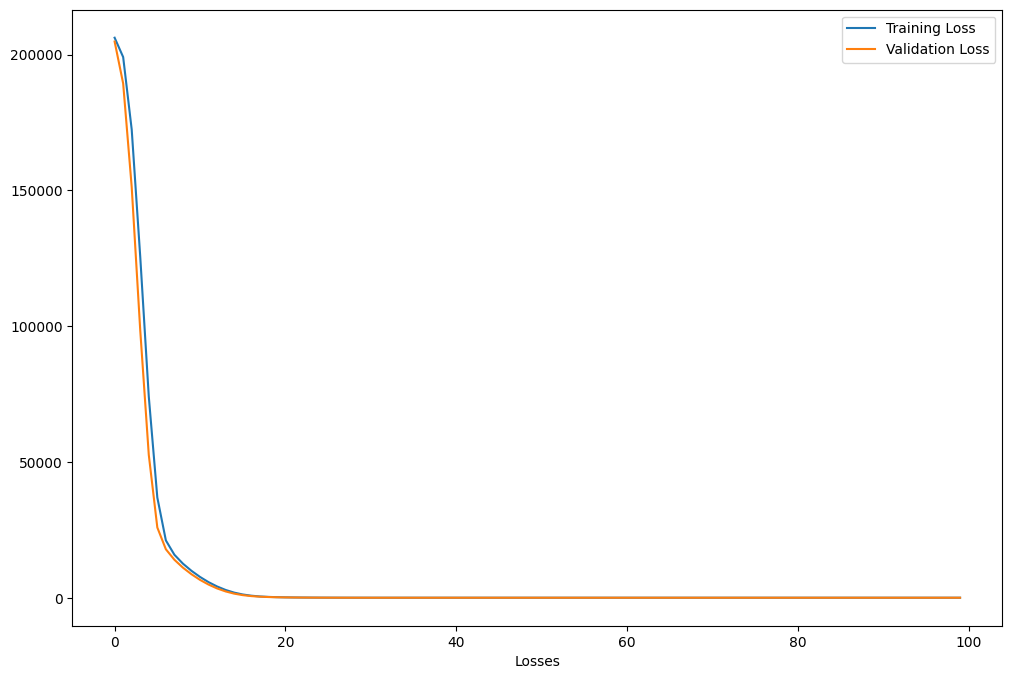

In [19]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.figure(figsize=(12,8))
plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.xlabel("Losses")

plt.legend()

In [20]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

### Model Evaluation  
 1. Training MSE
 2. Testing MSE
 3. R^2 ---> r2_score

In [21]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE : ", train_mse_loss.item())
print("Testing MSE : ", test_mse_loss.item())    

Training MSE :  20.847110748291016
Testing MSE :  19.39409828186035


In [22]:
from sklearn.metrics import r2_score

print("r^2 score = ", r2_score(y_test, test_preds))

r^2 score =  0.9322226320940991


In [23]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.769745,433.27
1,437.157654,438.16
2,460.851379,458.42
3,475.602905,480.82
4,435.449829,441.41
...,...,...
1909,451.423706,456.70
1910,432.002350,438.04
1911,467.718018,467.80
1912,431.413879,437.14
